In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO


In [9]:

# Load  CSV data 
df = pd.read_csv('Loan Prediction Dataset.csv')

# If Credit_History is 1, they have an 80% chance of approval.
# If Credit_History is 0 (or missing), they have a 15% chance of approval.
np.random.seed(42)  # For reproducibility
prob = df['Credit_History'].fillna(0).apply(lambda x: 0.80 if x == 1 else 0.15)
df['Loan_Status'] = np.random.binomial(1, prob)

# Map target to readable labels for visualization, we will encode it back to 0/1 later
df['Loan_Status_Label'] = df['Loan_Status'].map({1: 'Y', 0: 'N'})

print(f"Dataset shape: {df.shape}")
print(df['Loan_Status_Label'].value_counts())

Dataset shape: (367, 14)
Loan_Status_Label
Y    250
N    117
Name: count, dtype: int64


In [10]:
# Handle Categorical Missing Values 
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Handle Numerical Missing Values (Impute with Median)
numerical_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Drop Loan_ID as it is a unique identifier and not predictive
df.drop('Loan_ID', axis=1, inplace=True)

print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Loan_Status_Label    0
dtype: int64


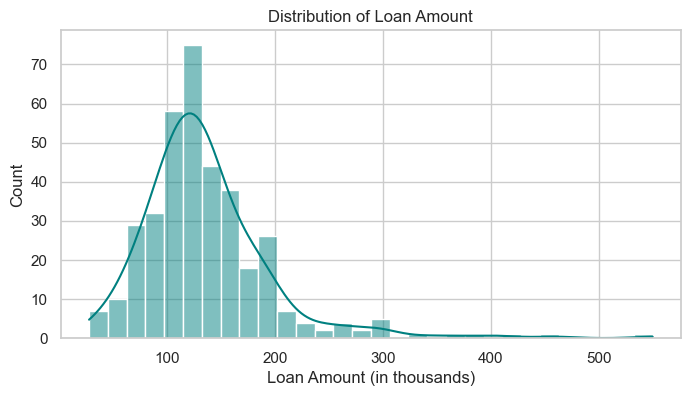

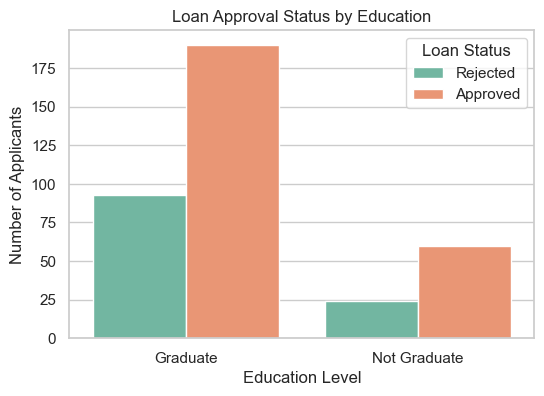

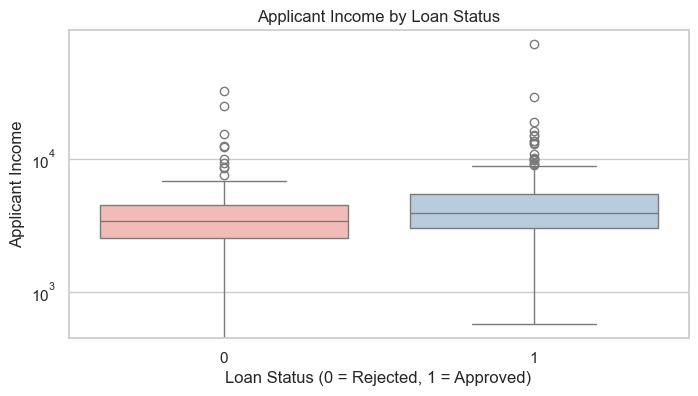

In [11]:
# Set the visual style
sns.set_theme(style="whitegrid")

# 1. Distribution of Loan Amount
plt.figure(figsize=(8, 4))
sns.histplot(df['LoanAmount'], kde=True, color='teal', bins=30)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount (in thousands)')
plt.ylabel('Count')
plt.show()

# 2. Loan Approval Status by Education
plt.figure(figsize=(6, 4))
sns.countplot(x='Education', hue='Loan_Status', data=df, palette='Set2')
plt.title('Loan Approval Status by Education')
plt.xlabel('Education Level')
plt.ylabel('Number of Applicants')
# Customizing the legend to show 'Rejected' and 'Approved' instead of 0 and 1
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
plt.show()

# 3. Applicant Income by Loan Status
plt.figure(figsize=(8, 4))
sns.boxplot(
    x='Loan_Status', 
    y='ApplicantIncome', 
    data=df, 
    hue='Loan_Status',
    palette='Pastel1', 
    legend=False
)
plt.title('Applicant Income by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Applicant Income')
plt.yscale('log')  # Log scale to handle high-income outliers
plt.show()

In [12]:
#Data Preprocessing
# Clean 'Dependents' column (convert '3+' to 3 and cast to integer)
df['Dependents'] = df['Dependents'].astype(str).str.replace('+', '', regex=False).astype(int)

# Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

encode_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
for col in encode_cols:
    df[col] = le.fit_transform(df[col])

# Drop the temporary label column used for visualization
df.drop('Loan_Status_Label', axis=1, inplace=True)

# Separate features (X) and target (y)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split the dataset into train and test sets (80% training, 20% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Accuracy: 82.43%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.50      0.65        24
           1       0.80      0.98      0.88        50

    accuracy                           0.82        74
   macro avg       0.86      0.74      0.77        74
weighted avg       0.84      0.82      0.81        74



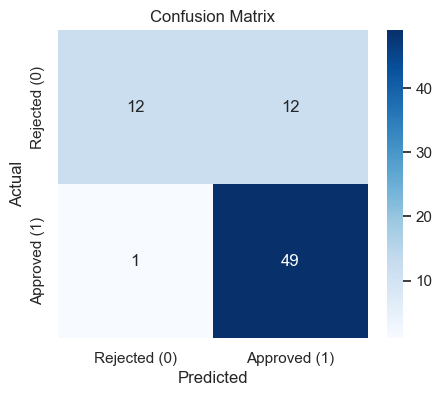

In [13]:
#Train and Evaluate the Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train the model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()